In [15]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

import matplotlib
matplotlib.rcParams.update({'font.size': 10, 'text.usetex': True, 'font.family': 'serif', 'font.serif': ['Computer Modern'], 'figure.figsize': (10,10)})


from koala import plotting as pl
from koala import graph_utils as gu
from koala.pointsets import uniform
from koala.graph_color import edge_color
from koala.voronization import generate_lattice

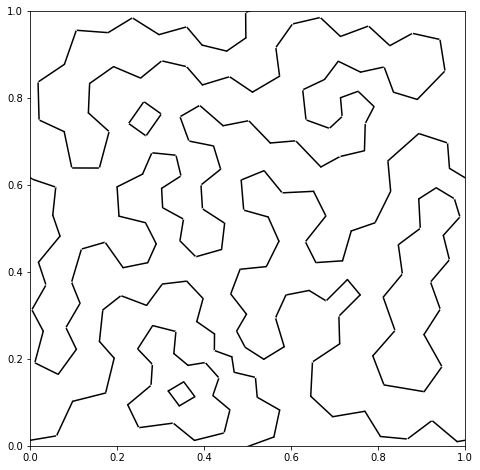

In [2]:
points = uniform(100)
lattice = generate_lattice(points)
lattice = gu.lloyd_relaxation(lattice, 10)

coloring = edge_color(lattice)
coloring = coloring[1]
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect("equal")
pl.plot_edges(lattice, ax=ax, labels = coloring, color_scheme=['w','k','k'])

plt.savefig("amorphous_colouring.pdf")

44
1500


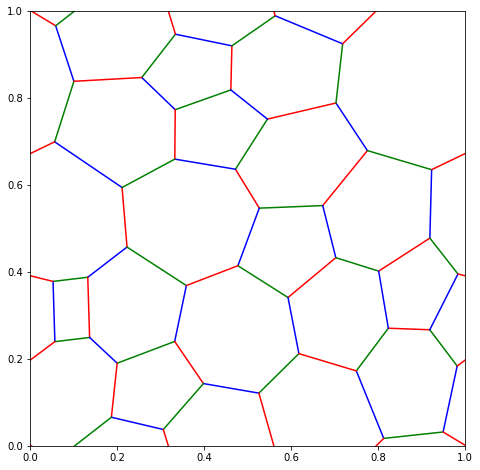

In [3]:
points = uniform(22)
lattice = generate_lattice(points)
lattice = gu.lloyd_relaxation(lattice, 10)

print(lattice.n_vertices)

coloring = edge_color(lattice,all_solutions=True)
c = coloring[1][0]
print(coloring[1].shape[0])
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect("equal")
pl.plot_edges(lattice, ax=ax, labels = c, color_scheme=['r','g','b'])

plt.savefig("amorphous_colouring.pdf")

In [25]:
n_repeats = 50

n_range = np.arange(4,30)

output = np.zeros((len(n_range),6))
for n in tqdm(n_range):
    num_out = []
    n_sites = n*2
    for x in range(n_repeats):
        points = uniform(n)
        lattice = generate_lattice(points,shift_vertices=False)
        coloring = edge_color(lattice,all_solutions=True)
        n_colourings = coloring[1].shape[0]
        num_out.append(n_colourings)
    
    min, max = np.min(num_out), np.max(num_out)
    upper_lower_quartile = np.percentile(num_out, [25, 75])
    avg_num = np.mean(num_out)

    output[n-4,0] = n_sites
    output[n-4,1] = min
    output[n-4,2] = max
    output[n-4,3] = upper_lower_quartile[0]
    output[n-4,4] = upper_lower_quartile[1]
    output[n-4,5] = avg_num




100%|██████████| 26/26 [19:20<00:00, 44.64s/it] 


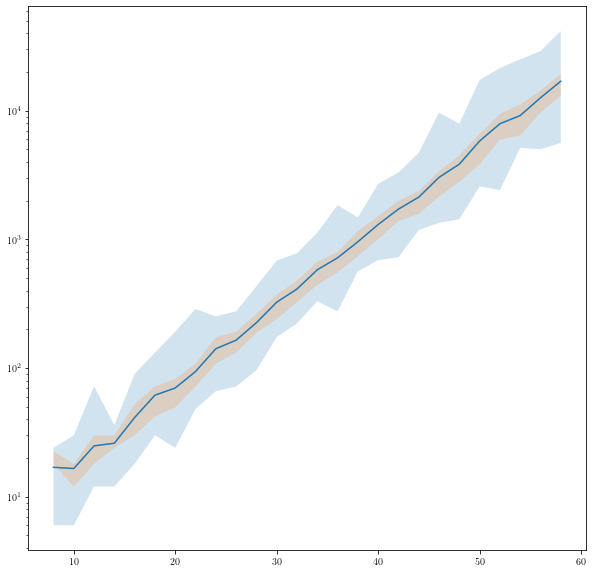

In [26]:
plt.plot(output[:,0], output[:,5])
plt.fill_between(output[:,0], output[:,1], output[:,2], alpha=0.2)
plt.fill_between(output[:,0], output[:,3], output[:,4], alpha=0.2)

# plt.plot(output[:,0], func(output[:,0]))

plt.yscale('log')

In [23]:
# fit straight line with polyfit

from scipy.optimize import curve_fit

means = np.log(output[:,5])
n_sites = output[:,0]

a,b = np.polyfit(n_sites, means, 1)

func = lambda x: np.exp(a*x + b)
a

0.1429086604437363